# Evaluación del modelo DenseNet121 baseline

Este notebook tiene como objetivo evaluar el desempeño del modelo DenseNet121 entrenado bajo el protocolo experimental definido. La evaluación se realiza utilizando el conjunto de prueba independiente del dataset MMOTU_OTU_2D_experimental.

## Configuración del entorno

Se configura el entorno de ejecución y se cargan los módulos desarrollados durante la etapa de entrenamiento.

In [2]:
from pathlib import Path
import sys
import torch


PROJECT_DIR = Path("../../../..").resolve()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print(PROJECT_DIR)
print(device)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification
cuda


## Importación de componentes

In [3]:
from src.classification.transforms import (
    get_classification_transforms
)

from src.classification.dataset import (
    MMOTUClassificationDataset
)

from src.classification.dataloader import (
    create_dataloader
)

from src.classification.models import (
    create_densenet121_classifier
)

from src.classification.evaluate import (
    predict,
    evaluate_predictions
)

## Preparación del conjunto de prueba

La evaluación final utiliza únicamente el conjunto test definido previamente.

In [4]:
DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "MMOTU_OTU_2D_experimental"
)


CSV_PATH = (
    PROJECT_DIR /
    "configs" /
    "splits" /
    "mmotu_experimental_split_standard.csv"
)

In [5]:
transform = get_classification_transforms()

test_dataset = MMOTUClassificationDataset(
    csv_file=CSV_PATH,
    image_dir=DATA_DIR,
    split="test",
    transform=transform
)

In [6]:
test_loader = create_dataloader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print(
    "Número de muestras test:",
    len(test_dataset)
)

Número de muestras test: 469


## Carga del modelo DenseNet121 entrenado

Se carga el checkpoint correspondiente al mejor modelo obtenido durante el entrenamiento.

In [7]:
MODEL_PATH = (
    PROJECT_DIR /
    "models" /
    "classification" /
    "densenet121_baseline_best.pth"
)

In [8]:
model = create_densenet121_classifier(
    pretrained=False,
    num_classes=2
)


model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)


model = model.to(device)

model.eval()

/tmp/ipykernel_246116/3166168082.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [19]:
print(model.classifier)

Linear(in_features=1024, out_features=2, bias=True)


## Generación de predicciones

La probabilidad de malignidad será utilizada para calcular métricas como ROC-AUC.

In [9]:
y_true, y_pred, y_prob = predict(
    model,
    test_loader,
    device
)


print(
    len(y_true),
    len(y_pred)
)

469 469


## Métricas de evaluación

Se calculan métricas adecuadas para conjuntos con distribución desbalanceada:

- Balanced Accuracy.
- ROC-AUC.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.

In [10]:
results = evaluate_predictions(y_true, y_pred, y_prob)

In [11]:
results["classification_report"]

'              precision    recall  f1-score   support\n\n      benign       0.92      0.96      0.94       421\n   malignant       0.45      0.29      0.35        48\n\n    accuracy                           0.89       469\n   macro avg       0.69      0.63      0.65       469\nweighted avg       0.87      0.89      0.88       469\n'

In [12]:
print(
    "Balanced Accuracy:",
    results["balanced_accuracy"]
)

print(
    "ROC-AUC:",
    results["roc_auc"]
)

Balanced Accuracy: 0.6256433095803642
ROC-AUC: 0.754602137767221


## Matriz de confusión

La matriz de confusión permite analizar los errores cometidos por el modelo, especialmente los falsos negativos correspondientes a muestras malignas clasificadas incorrectamente como benignas.

In [13]:
results["confusion_matrix"]

array([[404,  17],
       [ 34,  14]])

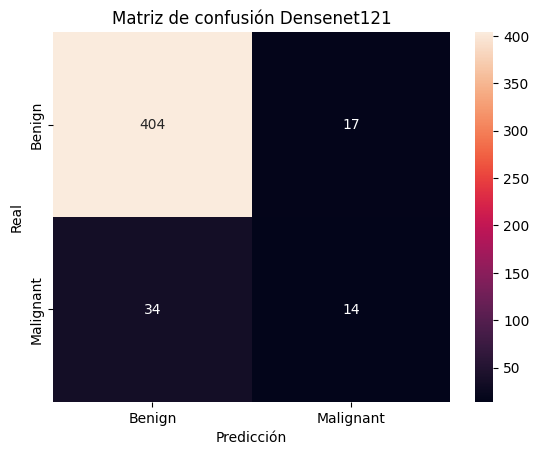

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = results["confusion_matrix"]


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión Densenet121")
plt.show()

## Almacenamiento de resultados experimentales

Los resultados obtenidos durante la evaluación son almacenados para mantener la trazabilidad del experimento y facilitar la comparación posterior con otras arquitecturas CNN.

In [15]:
import json

RESULT_DIR = (
    PROJECT_DIR /
    "results" /
    "classification" /
    "densenet121_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(RESULT_DIR)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/classification/densenet121_baseline


In [16]:
# Guardar métricas de evaluación
metrics = {
    "balanced_accuracy": results["balanced_accuracy"],
    "roc_auc": results["roc_auc"]
}

with open(
    RESULT_DIR / "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [17]:
# Guardar matriz de confusión
import pandas as pd


cm_df = pd.DataFrame(
    results["confusion_matrix"],
    index=[
        "Real_Benign",
        "Real_Malignant"
    ],
    columns=[
        "Pred_Benign",
        "Pred_Malignant"
    ]
)


cm_df.to_csv(
    RESULT_DIR /
    "confusion_matrix.csv"
)

In [18]:
# Guardar el reporte
with open(
    RESULT_DIR /
    "classification_report.txt",
    "w"
) as f:

    f.write(
        results["classification_report"]
    )

## Conclusión

El modelo alcanzó una exactitud global de 0.89. Sin embargo, debido al desbalance presente en el conjunto de datos, esta métrica no representa completamente la capacidad de detección de la clase maligna. Por ello, se consideraron métricas complementarias como Balanced Accuracy y las métricas específicas por clase.

Para la clase maligna, DenseNet121 obtuvo un recall de 0.29 y un F1-score de 0.35, identificando correctamente 14 de las 48 muestras malignas presentes en el conjunto de prueba. Asimismo, la matriz de confusión mostró 34 falsos negativos, correspondientes a muestras malignas clasificadas como benignas.

El modelo obtuvo una Balanced Accuracy de 0.626 y un ROC-AUC de 0.755, evidenciando que la arquitectura logra cierta capacidad de discriminación entre clases, aunque mantiene dificultades para detectar correctamente muestras malignas bajo la configuración baseline evaluada.